# 04-01 - The Scene and Its Labels

On Monday Lecture 04 taught a classifier as a rule in feature space, and it taught it on one scene. The town of Princeton in the Sentinel-2 pass of 22 August 2025, every cell a row of eight numbers, and a land cover map that somebody else made standing in for the truth. The lecture drew the four class means in the plane of red against near infrared, watched the nearest mean rule get about three cells in four right, grew a tree and then a forest, and asked where the labels had come from. On Wednesday the same scene comes to your laptop. This notebook is the training data. It opens the scene, builds the eight numbers per cell, reads the labels off the map, looks at where the four classes sit, and holds the map against a second map of the same town that reads it differently. 04-02 cuts the scene into chips, and 04-03 trains the forest.

We open the two files of the scene and read back from their tags what the twelve lines of Lecture 03 did to them, we build the eight features the lecture named and count the cells inside the town, we read the WorldCover map, collapse its eleven classes to four and map them, we draw three hundred cells of each class in the plane of red against near infrared, and we read a second map of the same town and see how far two authors can disagree about one place.

The ground truth file carries the numbers the lecture quoted, and every value we compute is printed beside its reference. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

The reference numbers first, because every count below is checked against them:

In [2]:
reference = json.load(open("data/ground_truth.json"))["p04"]
print(f"the scene of {reference['scene']['date']}, catalogue item {reference['scene']['item']}; the leaf-off scene of {reference['scene']['leaf_off_date']} waits for 04-03")
print(f"the labels are {reference['labels']['source']}; the second map is {reference['labels']['second_map']}")

the scene of 2025-08-22, catalogue item S2C_18TWK_20250822_0_L2A; the leaf-off scene of 2025-03-10 waits for 04-03
the labels are ESA WorldCover 2021 v200, 10 m; the second map is Impact Observatory annual land use and land cover 2023, 10 m


## The scene, and the twelve lines of Lecture 03

Lecture 03 pulled Princeton from orbit in twelve lines. Search the catalogue for a month of passes, open one item's window with `odc.stac.load`, apply the scale and the offset from the item, look. The pipeline that built this kit ran those lines once for the pass of 22 August 2025 and saved the town's window, in two files because the satellite records its bands at two sizes. Blue, green, red and near infrared at 10 m are in the first, the two shortwave infrared bands and the scene classification at 20 m in the second. A file that was made this way should say so about itself, so open the first one and ask:

In [3]:
with rasterio.open("data/s2_20250822_town_10m.tif") as f:
    print("coordinate system ", f.crs, "  reference", reference["scene"]["crs"])
    print("size              ", f.width, "columns by", f.height, "rows,", f"{f.width * f.height:,}", "cells   reference",
          reference["scene"]["width"], "by", reference["scene"]["height"], "rows,", f"{reference['scene']['cells']:,}", "cells")
    print("cell              ", f.res[0], f.crs.linear_units, "  reference", reference["scene"]["res_m"], "m")
    print("bands             ", ", ".join(f.descriptions))
    print()
    tags = f.tags()
    print(f"{'item':18} {tags['item']}   reference {reference['scene']['item']}")
    print(f"{'datetime':18} {tags['datetime']}")
    print(f"{'platform':18} {tags['platform']}   reference {reference['scene']['platform']}")
    print(f"{'cloud cover':18} {float(tags['cloud_cover']):.2f} percent of the tile   reference {reference['scene']['cloud_cover_percent']}")
    print(f"{'note':18} {tags['note']}")
    print(f"{'scale_offset_note':18} {tags['scale_offset_note']}")
    scene = {name: f.read(i + 1).astype("float32") for i, name in enumerate(["blue", "green", "red", "nir"])}
    transform, crs, shape = f.transform, f.crs, (f.height, f.width)
    extent = (f.bounds.left, f.bounds.right, f.bounds.bottom, f.bounds.top)

coordinate system  EPSG:32618   reference EPSG:32618
size               930 columns by 998 rows, 928,140 cells   reference 930 by 998 rows, 928,140 cells
cell               10.0 metre   reference 10 m
bands              blue reflectance, green reflectance, red reflectance, nir reflectance

item               S2C_18TWK_20250822_0_L2A   reference S2C_18TWK_20250822_0_L2A
datetime           2025-08-22T16:02:21.073000+00:00
platform           sentinel-2c   reference sentinel-2c
cloud cover        0.03 percent of the tile   reference 0.03
note               reflectance after the item's raster:bands scale, and its offset unless earthsearch:boa_offset_applied
scale_offset_note  reflectance, the item's scale and offset already applied; do not apply them again


The item is the catalogue's name for the pass, and it is readable. S2C is the third Sentinel-2 satellite, 18TWK the tile of the military grid that the lecture drew Princeton into, then the date. The window is nine hundred and thirty columns by nine hundred and ninety eight rows of 10 m cells in UTM zone 18 north, and it covers the bounding box of the municipal boundary with the town inside it, so about half of its cells lie outside the town and will be masked away below. The cloud cover is the tile's rather than the town's, and it is close to zero, which is why this pass was chosen among the fifteen of that August. The two notes are the lecture's rule in writing. The numbers in this file are reflectance, the item's scale and offset were applied once by the pipeline, and applying them again would be the mistake that 03-02 warned about.

Now the second file, whose grid has half as many rows and columns because its cells are twice as wide:

In [4]:
with rasterio.open("data/s2_20250822_town_20m.tif") as f:
    print("size              ", f.width, "columns by", f.height, "rows, cell", f.res[0], f.crs.linear_units)
    print("bands             ", "; ".join(f.descriptions))
    print("classes           ", f.tags()["scl_classes"])
    scene["swir16"], scene["swir22"] = f.read(1).astype("float32"), f.read(2).astype("float32")
    scene["scl"] = f.read(3)
print()
for name in ("blue", "green", "red", "nir", "swir16", "swir22"):
    band = scene[name]
    print(f"{name:7} reflectance from {band.min():.3f} to {band.max():.3f}, median {np.median(band):.3f}")

size               465 columns by 499 rows, cell 20.0 metre
bands              swir16 reflectance; swir22 reflectance; scene classification, classes as in s2_2025_items.json
classes            0 no data, 1 saturated or defective, 2 dark, 3 cloud shadow, 4 vegetation, 5 not vegetated, 6 water, 7 unclassified, 8 cloud medium, 9 cloud high, 10 thin cirrus, 11 snow

blue    reflectance from 0.000 to 1.769, median 0.024
green   reflectance from 0.000 to 1.668, median 0.045
red     reflectance from 0.000 to 1.610, median 0.027
nir     reflectance from 0.005 to 1.550, median 0.284
swir16  reflectance from 0.008 to 1.424, median 0.156
swir22  reflectance from 0.000 to 1.505, median 0.076


The two shortwave infrared bands are where a roof and a road part company with a leaf, because water inside a leaf absorbs shortwave light and a dry surface does not, and they are the reason the lecture's forest will do better than a rule on red and near infrared alone. The third band is not a reflectance at all. It is the scene classification, the product's own opinion of what each 20 m cell is, from the class table printed above, and it comes back in a moment as a baseline that nobody trained.

The pinned files are the pinned lane, and every number in this kit is computed from them. The live lane is the twelve lines themselves. It searches Earth Search for exactly this item, loads the four 10 m bands over the town, reads the two numbers on the item, a scale and an offset for every band, applies them once, and saves the result beside the pinned file. The pattern is the one A01 taught, fetch once, save, then read the saved copy, because a catalogue is a service rather than a dataset and a notebook that fetches on every run cannot be run again next week. Set the switch in the next cell to `True` if you want to watch the lines run, and set it back afterwards. Nothing below depends on it. The pinned copy stands in either way, and both lanes are fully accepted.

In [5]:
USE_LIVE_STAC = False   # True fetches the scene once from Earth Search and saves it in the data folder; set it back to False afterwards
EARTH_SEARCH = "https://earth-search.aws.element84.com/v1"   # the catalogue of Lecture 03, open to anyone, no token

The indented lines belong to the `if`, so with the switch at `False` the cell only reports that the pinned copy stands in. With it at `True` the cell needs a network, and if the catalogue is slow or away it says so and saves nothing:

In [6]:
if USE_LIVE_STAC:
    import pystac_client
    import odc.stac

    try:
        town_ll = gpd.read_file("data/princeton_boundary.geojson")           # the boundary in longitude and latitude, as a catalogue wants it
        catalog = pystac_client.Client.open(EARTH_SEARCH)
        found = list(catalog.search(collections=["sentinel-2-l2a"], ids=[reference["scene"]["item"]], bbox=list(town_ll.total_bounds)).items())
        if not found:
            raise ValueError(f"the catalogue returned nothing for {reference['scene']['item']}")
        item = found[0]
        print(f"found {item.id}, {item.datetime:%Y-%m-%d}, cloud cover {item.properties['eo:cloud_cover']:.2f} percent of the tile")

        bands = ["blue", "green", "red", "nir"]
        counts = odc.stac.load([item], bands=bands, crs=str(crs), resolution=reference["scene"]["res_m"],
                               x=(extent[0], extent[1]), y=(extent[2], extent[3]))   # the pinned file's own window, so the two can be compared cell for cell
        flagged = bool(item.properties.get("earthsearch:boa_offset_applied", False))
        layers = []
        for band in bands:
            raster = item.assets[band].extra_fields["raster:bands"][0]         # the two numbers on the item
            scale, offset = float(raster.get("scale", 1.0)), float(raster.get("offset", 0.0))
            dn = counts[band].isel(time=0).values.astype("float32")             # the stored counts, as the satellite sent them
            valid = dn[dn > 0]
            already_removed = flagged or (offset < 0 and valid.size > 0 and valid.min() < abs(offset) / scale)
            print(f"{band:6} scale {scale}  offset {offset}  " + ("the archive already took the offset off the counts, so it is not applied again" if already_removed else "both applied once"))
            layers.append(dn * scale + (0.0 if already_removed else offset))    # reflectance, once and never again

        geobox = counts.odc.geobox
        with rasterio.open(Path("data") / "my_scene_10m.tif", "w", driver="GTiff", width=geobox.width, height=geobox.height, count=4,
                           dtype="float32", crs=str(geobox.crs), transform=geobox.affine, compress="deflate") as out:
            for i, (band, layer) in enumerate(zip(bands, layers), start=1):
                out.write(layer, i)
                out.set_band_description(i, f"{band} reflectance")
            out.update_tags(item=item.id, datetime=item.datetime.isoformat(), platform=item.properties.get("platform", ""),
                            scale_offset_note="reflectance, the item's scale and offset already applied; do not apply them again")
        print("saved data/my_scene_10m.tif. Now set USE_LIVE_STAC = False; the notebook reads the pinned copy from disk either way, and the two files agree to the last cell.")

    except Exception as error:
        print(f"the fetch did not work. {type(error).__name__}: {error}")
        print("Nothing was saved; the pinned copy stands in, and both lanes are fully accepted.")
else:
    print("the live lane is off; the pinned copy of the scene stands in")

the live lane is off; the pinned copy of the scene stands in


Whichever line printed, nothing went wrong. If you took the live lane, the two numbers it printed for every band are the scale and the offset the item lists, the same for all four bands of a Sentinel-2 item, and the words beside them say whether the offset still had to come off the counts or the archive had already taken it off, which is the clause at the end of the pinned file's note. Either way the cell applied what was left to apply once, before saving, exactly as the pipeline did. The rest of the notebook reads the pinned copy, so that everyone in the room works on the same numbers, and since the cell loaded the same window onto the same grid, a cell of your own can open the file you saved and confirm that the two agree cell for cell.

## Eight numbers per cell

Lecture 04's Features and Labels frame put it in one line. A pixel is a row of numbers, here six reflectances and two indices. The six reflectances are the four bands of the first file and the two of the second, and since the second file's cells are twice as wide, each of its numbers is repeated two by two onto the 10 m grid, which gives every 10 m cell a shortwave value without inventing one. The two indices are the NDVI of 03-02, near infrared minus red over their sum, and its cousin for built ground, NDBI, shortwave infrared minus near infrared over their sum, which is high where a roof or a road reflects the shortwave band more strongly than the near infrared and low wherever a leaf does the opposite. The function builds the eight as one stack of layers, in the order the reference names them, and marks a cell with no red or no near infrared as missing, since neither index exists there:

In [7]:
FEATURES = ["blue", "green", "red", "nir", "swir16", "swir22", "ndvi", "ndbi"]

def features(scene):
    '''Eight layers of rows by columns, float32, in the order of FEATURES; the 20 m bands repeated 2 by 2 onto the
    10 m grid, and every feature NaN where red or near infrared is zero or less.'''
    up = lambda a: np.repeat(np.repeat(a, 2, axis=0), 2, axis=1)
    b, g, r, n = scene["blue"], scene["green"], scene["red"], scene["nir"]
    s16, s22 = up(scene["swir16"]), up(scene["swir22"])
    with np.errstate(invalid="ignore", divide="ignore"):
        ndvi = (n - r) / (n + r)
        ndbi = (s16 - n) / (s16 + n)
    stack = np.stack([b, g, r, n, s16, s22, ndvi, ndbi])
    stack[:, (r <= 0) | (n <= 0)] = np.nan
    return stack

feat = features(scene)
print("features  ", feat.shape[0], "layers of", feat.shape[1], "rows by", feat.shape[2], "columns")
print("named     ", ", ".join(FEATURES), "   reference", ", ".join(reference["scene"]["features"]))
print()
print(f"{'':8}{'lowest':>9}{'median':>9}{'highest':>9}")
for name, layer in zip(FEATURES, feat):
    print(f"{name:8}{np.nanmin(layer):9.3f}{np.nanmedian(layer):9.3f}{np.nanmax(layer):9.3f}")

features   8 layers of 998 rows by 930 columns
named      blue, green, red, nir, swir16, swir22, ndvi, ndbi    reference blue, green, red, nir, swir16, swir22, ndvi, ndbi

           lowest   median  highest
blue        0.000    0.024    1.769
green       0.000    0.045    1.668
red         0.000    0.027    1.610
nir         0.005    0.284    1.550
swir16      0.008    0.156    1.424
swir22      0.000    0.076    1.505
ndvi       -0.502    0.833    0.999
ndbi       -0.691   -0.280    0.746


Read the table as the lecture's ten rows turned on their side. The three visible bands sit at a few percent, near infrared near a quarter, the shortwave bands between the two, and each reflectance's highest value climbs past one on a handful of roofs that throw the sun straight back, which is why every picture below is stretched to its percentiles rather than to its extremes. The NDVI median is high and the NDBI median negative, and both say the same thing, that most of this window is leaf.

The window is larger than the town, so the next step is the boundary. It is a polygon in longitude and latitude, the same file P01 opened, and `rasterize` burns it onto the scene's grid as a layer of true and false, which is the spatial join of P02 read the other way round, a cell asking which polygon it lies in. The scene classification band, repeated onto the 10 m grid in the same way as the shortwave bands, then gives a first count:

In [8]:
town = gpd.read_file("data/princeton_boundary.geojson").to_crs(crs)
mask = rasterize([(town.geometry.iloc[0], 1)], out_shape=shape, transform=transform, fill=0, dtype="uint8").astype(bool)
finite = np.isfinite(feat).all(axis=0)
scl = np.repeat(np.repeat(scene["scl"], 2, axis=0), 2, axis=1)

print(f"cells in the window                    {mask.size:,}   reference {reference['scene']['cells']:,}")
print(f"cells inside the town                  {mask.sum():,}   reference {reference['scene']['cells_in_town']:,}")
print(f"of them with all eight numbers finite  {(mask & finite).sum():,}")
print(f"the scene classification calls {100 * np.mean(scl[mask] == 4):.1f} percent of the town vegetation   reference {reference['scene']['scl_vegetation_percent']}")

cells in the window                    928,140   reference 928,140
cells inside the town                  476,595   reference 476,595
of them with all eight numbers finite  476,595
the scene classification calls 92.9 percent of the town vegetation   reference 92.9


Nearly half a million cells inside the town, out of the window's nine hundred thousand, every one of them with all eight numbers, and the reference agrees. The last line is the first classifier of this kit, and nobody in this room trained it. The scene classification band is the output of a model at ESA, and a rule that calls every cell it marks vegetation green and everything else not would be right about nine cells in ten of this town. The lecture set that bar on its baseline frame, and the forest of 04-03 has to clear it. Here is the scene, in true colour and as NDVI, with the boundary:

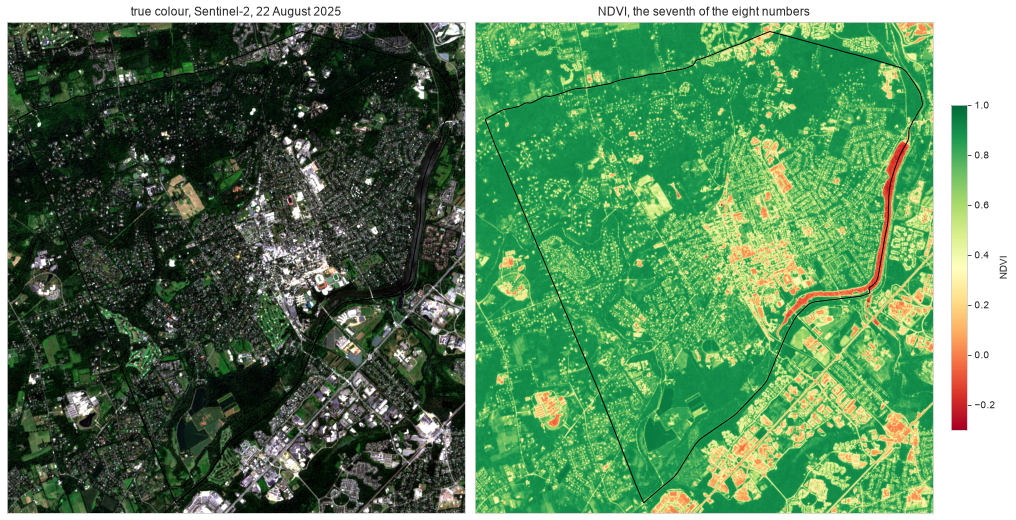

In [9]:
def stretch(bands):
    '''Three bands as rows by columns by colour, each stretched between its 2nd and 98th percentile. For the eye only.'''
    arr = np.stack(bands)
    lo, hi = np.nanpercentile(arr, 2, axis=(1, 2)), np.nanpercentile(arr, 98, axis=(1, 2))
    return np.moveaxis(np.clip((arr - lo[:, None, None]) / (hi - lo)[:, None, None], 0, 1), 0, -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7.6), layout="constrained")
axes[0].imshow(stretch([scene["red"], scene["green"], scene["blue"]]), extent=extent)
axes[0].set_title("true colour, Sentinel-2, 22 August 2025", fontsize=12)
im = axes[1].imshow(feat[6], extent=extent, cmap="RdYlGn", vmin=-0.3, vmax=1.0)
axes[1].set_title("NDVI, the seventh of the eight numbers", fontsize=12)
for ax in axes:
    town.boundary.plot(ax=ax, color="black", linewidth=1)
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=list(axes), shrink=0.6, pad=0.02, label="NDVI")

To you a cell is one square of this picture, with a neighbourhood around it and a memory of what the lawn looked like in March. To the machine it is its row of eight numbers and nothing else. Every rule of the lecture, the nearest mean, the tree's cuts, the forest's vote, is a rule on those eight numbers, and everything a classifier can know about a place has to be in them. That is why the features matter as much as the algorithm, and it is why 04-02 puts the neighbourhood back by cutting the scene into chips.

## The labels, a map somebody else made

The lecture's Where do labels come from frame listed four sources, and the first was an existing map, free, dated and made for another purpose. Ours is ESA WorldCover 2021, a global land cover map at 10 m produced by a classifier at ESA from the Sentinel-1 and Sentinel-2 passes of 2021, with eleven classes and an overall accuracy of about three quarters by its own validation. The pipeline relocated it onto the scene's grid by nearest neighbour, so that every cell of the scene has exactly one class code, and the file carries its provenance and its class table in its tags:

In [10]:
with rasterio.open("data/worldcover_2021_town_10m.tif") as f:
    for key in ("source", "licence", "retrieved", "citation", "resampling"):
        print(f"{key:10} {f.tags()[key]}")
    wc_classes = {int(k): v for k, v in json.loads(f.tags()["classes"]).items()}
    raw = f.read(1)
    same_grid = f.transform == transform and (f.height, f.width) == shape
print("same grid as the scene", same_grid)
print()
print("the classes of the map, and the share of the town's cells in each")
codes = [int(c) for c in np.unique(raw[mask])]
for code_, name in wc_classes.items():
    if code_ in codes:
        key = f"{code_} {name}"
        print(f"  {key:30} {100 * np.mean(raw[mask] == code_):6.2f} percent   reference {reference['labels']['raw_share_percent'][key]}")
    else:
        print(f"  {code_:<3} {name:26} not present in the town")

source     ESA WorldCover 10 m 2021 v200, Planetary Computer collection esa-worldcover
licence    CC BY 4.0, ESA WorldCover 2021 v200, Zanaga et al. 2022, doi 10.5281/zenodo.7254221
retrieved  2026-09-26
citation   Zanaga et al. 2022, doi 10.5281/zenodo.7254221
resampling nearest onto the Sentinel-2 town grid
same grid as the scene True

the classes of the map, and the share of the town's cells in each
  10 tree cover                   80.08 percent   reference 80.08
  20  shrubland                  not present in the town
  30 grassland                     9.57 percent   reference 9.57
  40 cropland                      1.82 percent   reference 1.82
  50 built-up                      7.11 percent   reference 7.11
  60 bare or sparse vegetation     0.04 percent   reference 0.04
  70  snow and ice               not present in the town
  80 permanent water bodies        1.38 percent   reference 1.38
  90  herbaceous wetland         not present in the town
  95  mangroves                 

Four fifths of the town is tree cover. Grassland is a tenth, built-up a fourteenth, cropland and water a percent or two each, bare ground fewer than two hundred cells, and five of the eleven classes never occur here, which is what a global class system looks like on one small town. Read the built-up share twice, because a second map will contradict it below.

A label is a decision someone made, and the next decision is ours. The lecture's Informational and Spectral Classes frame drew the line between the classes an application needs and the clusters the data has, and the running example needs four informational classes. Tree cover stays tree cover. Grassland, cropland and herbaceous wetland become grass, because at 10 m on a summer scene over Princeton they are all low green vegetation and no rule on eight numbers should be asked to tell a hay field from a lawn. Built-up stays built-up, and permanent water bodies become water. Shrubland and bare ground are dropped rather than forced into a class they do not belong to, and the cost of dropping them is printed so that you can judge it:

In [11]:
WC_COLLAPSE = {10: 1, 30: 2, 40: 2, 90: 2, 50: 3, 80: 4}      # tree cover; grassland, cropland and wetland as grass; built-up; water
CLASSES = {1: "tree cover", 2: "grass", 3: "built-up", 4: "water"}
COLOURS = {1: "#2f7d32", 2: "#a8d05f", 3: "#b0413e", 4: "#3b6fb6"}

def collapse(arr, table):
    '''The map's codes to the four classes of the course, 0 for every code the table does not name.'''
    out = np.zeros(arr.shape, dtype="uint8")
    for code_, cls in table.items():
        out[arr == code_] = cls
    return out

lab = collapse(raw, WC_COLLAPSE)
lab[~mask] = 0                                                  # nothing outside the town carries a label
for code_, cls in WC_COLLAPSE.items():
    key = f"{code_} {wc_classes[code_]}"
    print(f"  {key:28} becomes {CLASSES[cls]:11} reference {reference['labels']['collapse'][key]}")
print()
for cls, name in CLASSES.items():
    print(f"{name:11} {100 * np.mean(lab[mask] == cls):5.1f} percent of the town   reference {reference['labels']['share_percent'][name]}")
print(f"{'dropped':11} {100 * np.mean(lab[mask] == 0):5.2f} percent of the town   reference {reference['labels']['dropped_percent']}")
labelled = (lab > 0) & finite
print()
print(f"cells labelled, with all eight numbers  {labelled.sum():,}   reference {reference['scene']['cells_labelled']:,}")

  10 tree cover                becomes tree cover  reference tree cover
  30 grassland                 becomes grass       reference grass
  40 cropland                  becomes grass       reference grass
  90 herbaceous wetland        becomes grass       reference grass
  50 built-up                  becomes built-up    reference built-up
  80 permanent water bodies    becomes water       reference water

tree cover   80.1 percent of the town   reference 80.1
grass        11.4 percent of the town   reference 11.4
built-up      7.1 percent of the town   reference 7.1
water         1.4 percent of the town   reference 1.4
dropped      0.04 percent of the town   reference 0.04

cells labelled, with all eight numbers  476,425   reference 476,425


The four shares add up to the town less the dropped cells, and the reference agrees to the decimal. The last line is the number of rows in the lecture's training table, every cell inside the town that carries one of the four classes and all eight numbers, and it is the count the Features and Labels frame quoted. Here is the label column as a map:

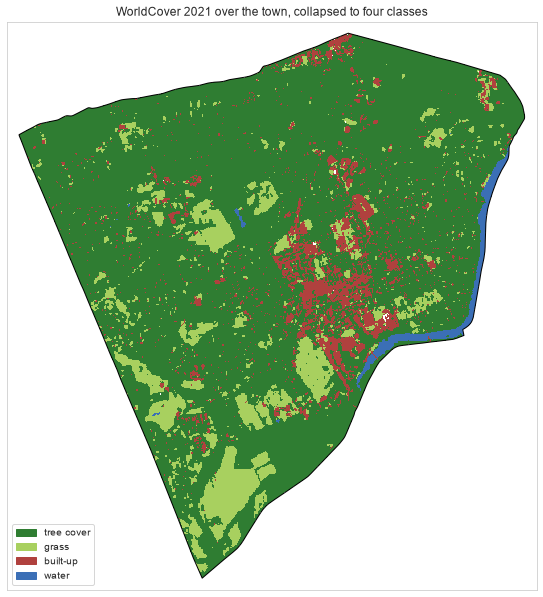

In [12]:
cmap = ListedColormap([COLOURS[cls] for cls in CLASSES])
legend = [Patch(color=COLOURS[cls], label=name) for cls, name in CLASSES.items()]

def class_map(ax, arr, title):
    '''One of the four-class maps, white where a cell carries no class.'''
    ax.imshow(np.ma.masked_equal(arr, 0), extent=extent, cmap=cmap, vmin=0.5, vmax=4.5, interpolation="nearest")
    town.boundary.plot(ax=ax, color="black", linewidth=1)
    ax.set_title(title, fontsize=12); ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(figsize=(8, 8.4))
class_map(ax, lab, "WorldCover 2021 over the town, collapsed to four classes")
ax.legend(handles=legend, loc="lower left", fontsize=10)
fig.tight_layout()

Look at it beside the true colour picture above. The map is mostly the dark green of tree cover, with the campus and the town centre red, the fields at the edges and the golf course pale green, and the lake blue along the southern boundary. It looks right, and that is the trap the lecture named on its provenance frame. This is not the ground. It is one classifier's reading of the scenes of 2021, at 10 m, with a stated accuracy of about three quarters, and every cell of it is about to become training data.

## Where the classes sit

Lecture 04's first rule was the nearest mean, in the plane of red against near infrared, and the frame that showed it drew the training cells as points and one mean per class. Here are three hundred cells of each class, drawn at random with the lecture's seed so that everyone's picture is the same, and the four class means computed on every labelled cell of the town:

tree cover  mean red 0.029   mean near infrared 0.277   on 381,645 cells
grass       mean red 0.049   mean near infrared 0.377   on 54,325 cells
built-up    mean red 0.115   mean near infrared 0.221   on 33,890 cells
water       mean red 0.026   mean near infrared 0.035   on 6,565 cells


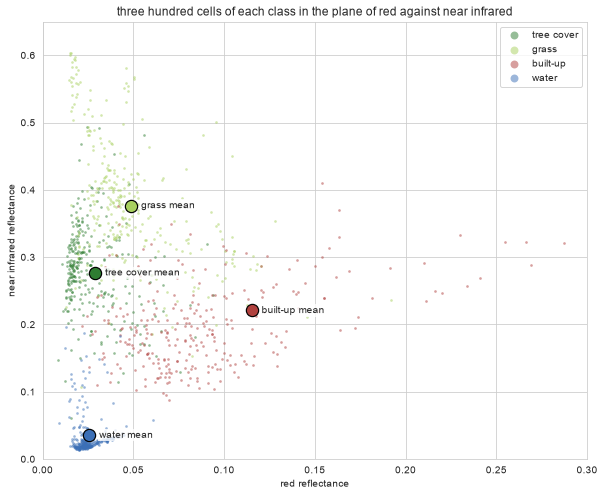

In [13]:
rng = np.random.default_rng(20260928)
red, nir = feat[2].ravel(), feat[3].ravel()
means, sizes = {}, {}
fig, ax = plt.subplots(figsize=(8.5, 7))
for cls, name in CLASSES.items():
    cells = np.flatnonzero(labelled & (lab == cls))
    means[name], sizes[name] = (red[cells].mean(), nir[cells].mean()), len(cells)
    pick = rng.choice(cells, 300, replace=False)
    ax.scatter(red[pick], nir[pick], s=7, color=COLOURS[cls], alpha=0.5, linewidths=0, label=name)
for cls, name in CLASSES.items():
    ax.scatter(*means[name], s=150, color=COLOURS[cls], edgecolor="black", linewidth=1.2, zorder=4)
    ax.annotate(f"{name} mean", means[name], xytext=(10, 0), textcoords="offset points", fontsize=10, va="center",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax.set_xlim(0, 0.3); ax.set_ylim(0, 0.65)
ax.set_xlabel("red reflectance"); ax.set_ylabel("near infrared reflectance")
ax.set_title("three hundred cells of each class in the plane of red against near infrared", fontsize=12)
ax.legend(loc="upper right", fontsize=10, markerscale=3)
fig.tight_layout()

for name, (r, n) in means.items():
    print(f"{name:11} mean red {r:.3f}   mean near infrared {n:.3f}   on {sizes[name]:,} cells")

Compare the four means with the table on the lecture's Learning as Geometry frame. The lecture's were computed on its training pool of three thousand cells per class, yours on every cell of the town, and they should agree to a few thousandths. Then read the cloud. Water sits alone by the origin, reflecting little of either band, and any rule finds it. Built-up is the wide diagonal, a dark road and a bright roof both being built-up, which is the frame's point that an informational class is several spectral classes. Tree cover and grass overlap most of the way, the grass a little higher and a little brighter, and their two means sit so close that the straight line between them cuts through both clouds. That overlap is where the nearest mean rule lost its cells on Monday, and it is why the forest of 04-03 will look at the other six numbers, the shortwave bands above all, where a crown, a lawn and a roof separate better than they do here.

## A second opinion

The lecture's Provenance frame held two maps of the same town against each other, and here they are. The Impact Observatory publishes an annual land cover map at 10 m from Sentinel-2, made by a deep network trained on labels its own annotators drew, and the pipeline relocated its map of 2023 onto the same grid. Its class system is not WorldCover's, so it needs a collapse table of its own, trees to tree cover, rangeland, crops and flooded vegetation to grass, built area to built-up, water to water:

source     Impact Observatory 10 m annual land use land cover 2023 (v02), Planetary Computer collection io-lulc-annual-v02
licence    CC BY 4.0, Impact Observatory annual land use and land cover 2023, Karra et al. 2021
retrieved  2026-09-26
citation   Karra et al. 2021, IGARSS, doi 10.1109/IGARSS47720.2021.9553499
the classes present in the town 1 water, 2 trees, 4 flooded vegetation, 5 crops, 7 built area, 11 rangeland

             Impact Observatory  reference   WorldCover
tree cover                 26.3       26.3         80.1
grass                       7.3        7.3         11.4
built-up                   64.7       64.7          7.1
water                       1.7        1.7          1.4

cells that both maps label  100.0 percent of the town   reference 100.0


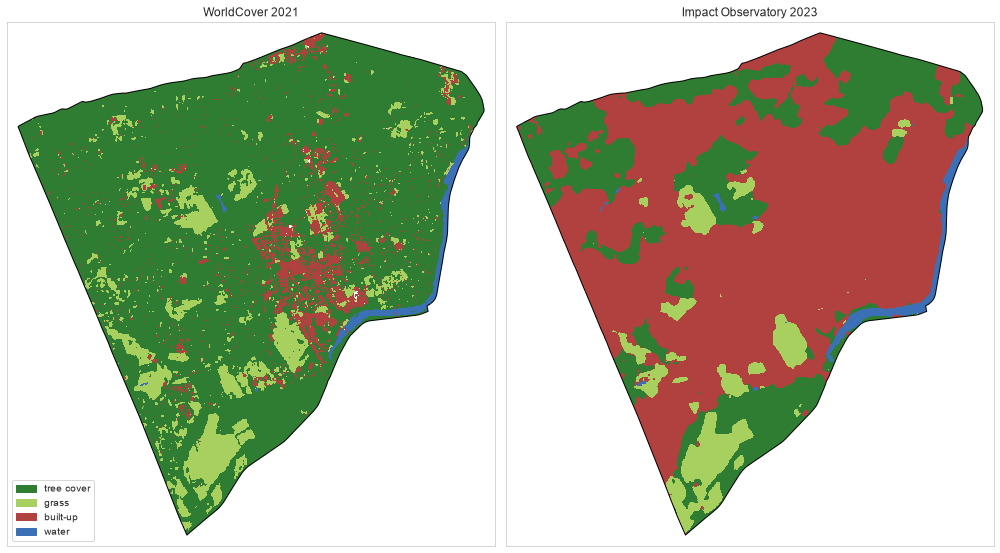

In [14]:
IO_COLLAPSE = {2: 1, 11: 2, 5: 2, 4: 2, 7: 3, 1: 4}            # trees; rangeland, crops and flooded vegetation as grass; built area; water
with rasterio.open("data/io_lulc_2023_town_10m.tif") as f:
    for key in ("source", "licence", "retrieved", "citation"):
        print(f"{key:10} {f.tags()[key]}")
    io_classes = {int(k): v for k, v in json.loads(f.tags()["classes"]).items()}
    raw_io = f.read(1)
print("the classes present in the town", ", ".join(f"{int(c)} {io_classes[int(c)]}" for c in np.unique(raw_io[mask])))
lab_io = collapse(raw_io, IO_COLLAPSE)
lab_io[~mask] = 0
print()
print(f"{'':11} {'Impact Observatory':>19} {'reference':>10} {'WorldCover':>12}")
for cls, name in CLASSES.items():
    print(f"{name:11} {100 * np.mean(lab_io[mask] == cls):19.1f} {reference['labels']['io_share_percent'][name]:10} {100 * np.mean(lab[mask] == cls):12.1f}")
both = (lab > 0) & (lab_io > 0)
print()
print(f"cells that both maps label  {100 * np.mean(both[mask]):.1f} percent of the town   reference {reference['labels']['both_labelled_percent']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 7.6))
class_map(axes[0], lab, "WorldCover 2021")
class_map(axes[1], lab_io, "Impact Observatory 2023")
axes[0].legend(handles=legend, loc="lower left", fontsize=10)
fig.tight_layout()

Two maps, one town, two years apart at most, and one of them says the town is two thirds built while the other says one fourteenth, built-up 64.7 percent against 7.1 in the reference. Neither is wrong about the pixels. The Impact Observatory's built area is a land use class in all but name. It labels the residential fabric, the streets and the houses and the trees over them, as one thing, and most of Princeton is exactly that. WorldCover labels each 10 m cell by what covers it, and over most of the residential fabric that is a tree crown. The lecture's line was that one map labels the canopy and the other the neighbourhood under it. A label has a date, a resolution and an author, and the same cell can carry two honest labels that disagree, so a report that says built-up 7 percent, or 65, has said nothing until it names the map. And a model trained on either map can at best agree with that map, which is the sentence to keep from the provenance frame.

## Your turn

Count the agreement. Keep the cells that both maps label, and compute the share of them on which the two collapsed maps give the same class. Then, for each of the four classes as WorldCover sees it, compute the share of its cells that the Impact Observatory map puts in the same class, and the sentence to write is which classes the two authors mean the same thing by, and which they do not.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [15]:
# Your attempt. lab is WorldCover in the four classes and lab_io the Impact Observatory map, both 0 where a cell has no class.
#
# both = (lab > ___) & (lab_io > ___)
# agree = lab[both] == lab_io[both]
# print(f"the two maps agree on {agree.mean():.1%} of the cells they both label")
#
# for cls, name in CLASSES.items():
#     here = both & (lab == ___)
#     print(f"{name:11} {(lab_io[here] == cls).mean():.1%} of WorldCover's cells get the same class from the other map")

## Check your understanding

1. The 10 m file holds reflectance with the offset already applied. A colleague pulls the same item live, applies the offset a second time and computes NDVI. In which direction does every index move, and which of the four classes moves most?
2. The shortwave infrared bands are repeated two by two onto the 10 m grid. What does a 10 m cell's shortwave value then measure, and what goes wrong for a cell on the edge of a roof?
3. WorldCover calls a golf fairway grassland and a soy field cropland, and the collapse calls both grass. Name a question about Princeton for which that decision is right and one for which it is wrong.
4. Two maps of the same town label 7.1 and 64.7 percent of it built-up. Write the one sentence a report should carry so that a reader knows which number to use for which purpose.

## Where we are

You can open a satellite scene and read from its tags what was done to it, build eight features per cell from two files on two grids, mask a scene to a boundary and count what is inside. You can read a land cover map with its class table, collapse its classes to the ones your question needs and say what the collapse decided, and you have seen four classes in feature space, two of them apart and two of them overlapping. And you have held two maps of the same town against each other and found that a label is an opinion with a date, a cell size and an author.

The habit worth keeping: before you train on a label, ask who made it, when, at what cell size and to what accuracy, and write the answer into the caption of every map that comes out.

In 04-02 we cut the scene into chips of sixteen cells, give each chip a label from the map and sixteen numbers from its features, and meet the tile bias of L02 on our own data.

## Further resources

Nothing in this course requires anything below.

Chapters 6 and 7 of Wu, GeoAI with Python, cover the machine learning vocabulary of this notebook and the classical classifiers, and both are on the course reading list: https://book.opengeoai.org

ESA WorldCover, the product page with the class definitions and the validation report behind the accuracy quoted above: https://esa-worldcover.org

The Impact Observatory map is described in Karra and colleagues, Global land use land cover with Sentinel 2 and deep learning, IGARSS 2021, doi 10.1109/IGARSS47720.2021.9553499.

Earth Search, the catalogue the live lane searches, which lists the item of this scene in its sentinel-2-l2a collection: https://earth-search.aws.element84.com/v1

The Sentinel-2 files in this folder contain modified Copernicus Sentinel data 2025. The land cover maps are ESA WorldCover 2021 v200 (Zanaga et al. 2022, CC BY 4.0) and the Impact Observatory annual land cover 2023 (Karra et al. 2021, CC BY 4.0). The municipal boundary is a public record of NJGIN.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The agreement of the two maps, computed from the files themselves so that the cell stands on its own:

```python
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize

with rasterio.open("data/worldcover_2021_town_10m.tif") as f:
    raw = f.read(1)
    town = gpd.read_file("data/princeton_boundary.geojson").to_crs(f.crs)
    mask = rasterize([(town.geometry.iloc[0], 1)], out_shape=(f.height, f.width), transform=f.transform, fill=0, dtype="uint8").astype(bool)
with rasterio.open("data/io_lulc_2023_town_10m.tif") as f:
    raw_io = f.read(1)

CLASSES = {1: "tree cover", 2: "grass", 3: "built-up", 4: "water"}

def collapse(arr, table):
    out = np.zeros(arr.shape, dtype="uint8")
    for code, cls in table.items():
        out[arr == code] = cls
    return out

lab = collapse(raw, {10: 1, 30: 2, 40: 2, 90: 2, 50: 3, 80: 4})
lab_io = collapse(raw_io, {2: 1, 11: 2, 5: 2, 4: 2, 7: 3, 1: 4})
lab[~mask] = 0
lab_io[~mask] = 0
both = (lab > 0) & (lab_io > 0)
print(f"the two maps agree on {np.mean(lab[both] == lab_io[both]):.1%} of the cells they both label")
for cls, name in CLASSES.items():
    here = both & (lab == cls)
    print(f"{name:11} {np.mean(lab_io[here] == cls):.1%} of WorldCover's cells get the same class from the other map")
```

About two fifths of the town, and the four lines under it say where the other three fifths went. Built-up and water are the classes the two authors mean the same thing by. Nearly every cell WorldCover calls built-up or water, the other map calls built area or water as well. Tree cover is where they part. The Impact Observatory map paints the residential fabric built where WorldCover sees the trees over it, so it agrees with only about a third of WorldCover's tree cells and calls most of the rest built area. Grass is split down the middle, because a lawn among houses is built area to one author and grassland to the other. Neither share is an accuracy, since neither map is the ground. It is the size of the disagreement between two reasonable readings of one town, and the forest of 04-03, trained on one of them, inherits that reading whole.